# Daylan et al. (2021b) TESS phase curve of WASP-121 b

This notebook reproduces the red-optical phase-curve measurements of Daylan et al. (2021b), *AJ*, 161, 131 (DOI 10.3847/1538-3881/abd8d2) from the public TESS Sector 7 SPOC PDCSAP light curve. Miletos retrieves and plots the observations, then PCAT samples a model with a limb-darkened transit (batman; Kreidberg 2015), the planet's dayside and nightside emission with a cosine phase variation and a free phase offset, the secondary eclipse, and stellar ellipsoidal variation. A quadratic stellar baseline per TESS orbit and white-noise jitter are marginalized in the likelihood. Brightness temperatures integrate Planck spectra over the TESS response for a stellar effective temperature of 6460 ± 140 K (Delrez et al. 2016). The paper reports 3012 (+40/−42) K on the dayside and 2022 (+254/−602) K on the nightside, with no significant phase offset.

In [1]:
from IPython.display import Image, display

from miletos import daylan2021b
from miletos.paths import get_repository_path

visual_path = get_repository_path() / 'examples' / 'WASP-121b' / 'visuals'

## Retrieve and plot the observations

Miletos writes the raw and phase-folded Sector 7 light curves.

Reading from /Users/tdaylan/Documents/work/git/miletos/examples/WASP-121b/visuals/RelativeFlux_Raw_TESS_WASP-121b-Daylan2021b.png...


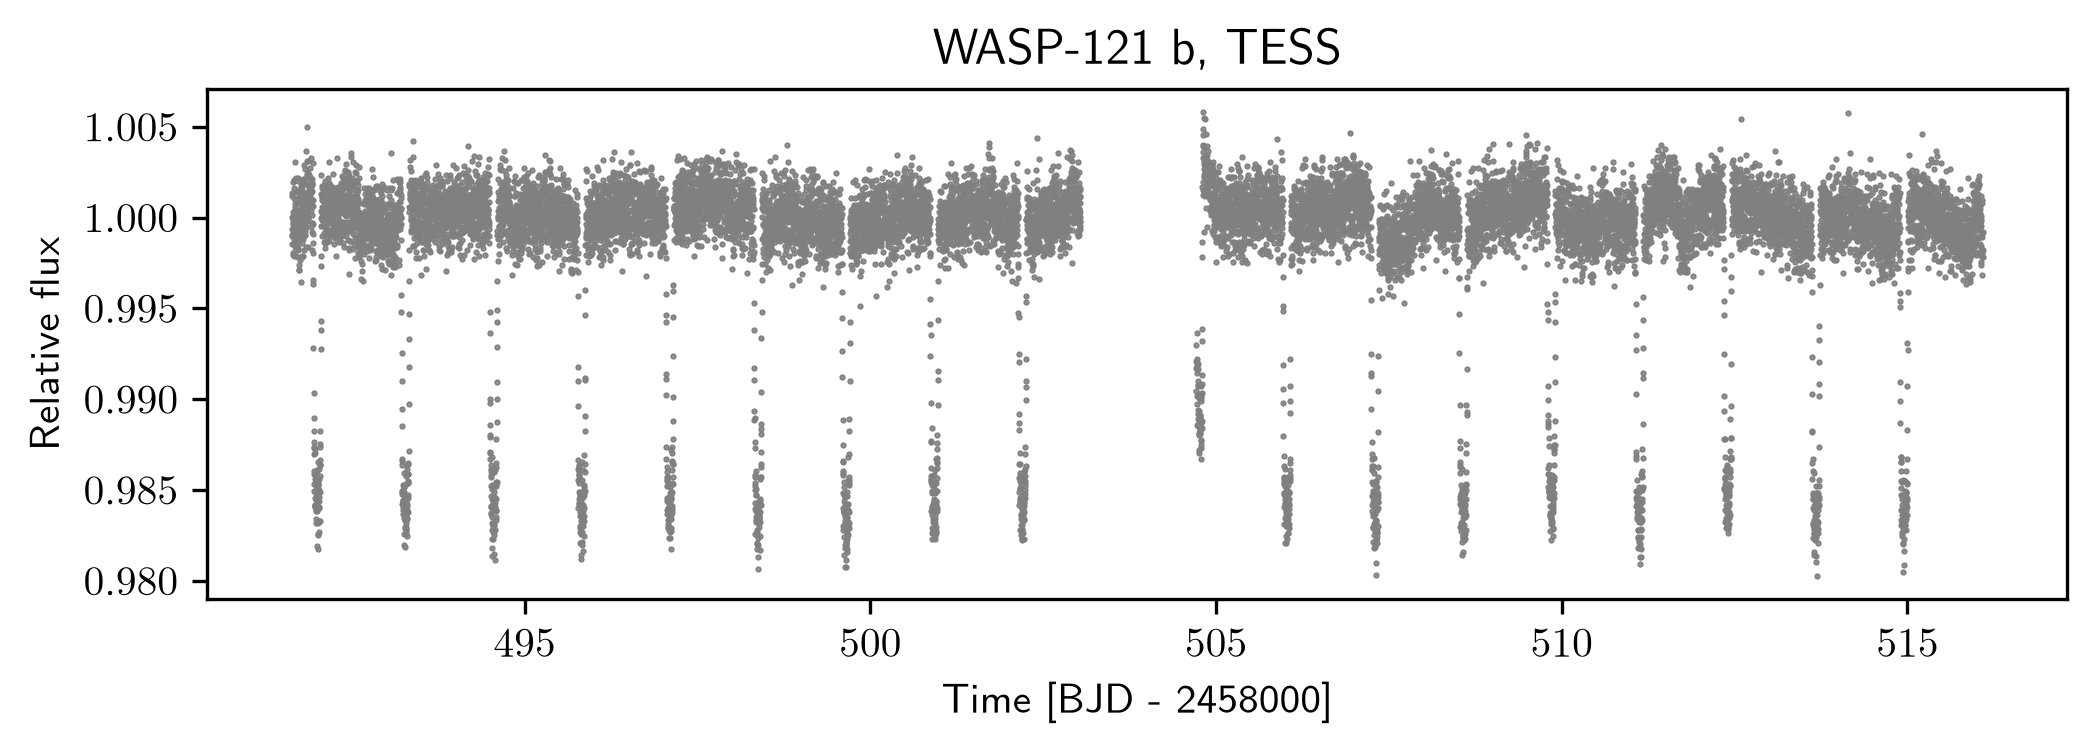

Reading from /Users/tdaylan/Documents/work/git/miletos/examples/WASP-121b/visuals/PhaseCurve_TESS_b_DetrendedPrimaryCenteredZoom_WASP-121b-Daylan2021b_exar.png...


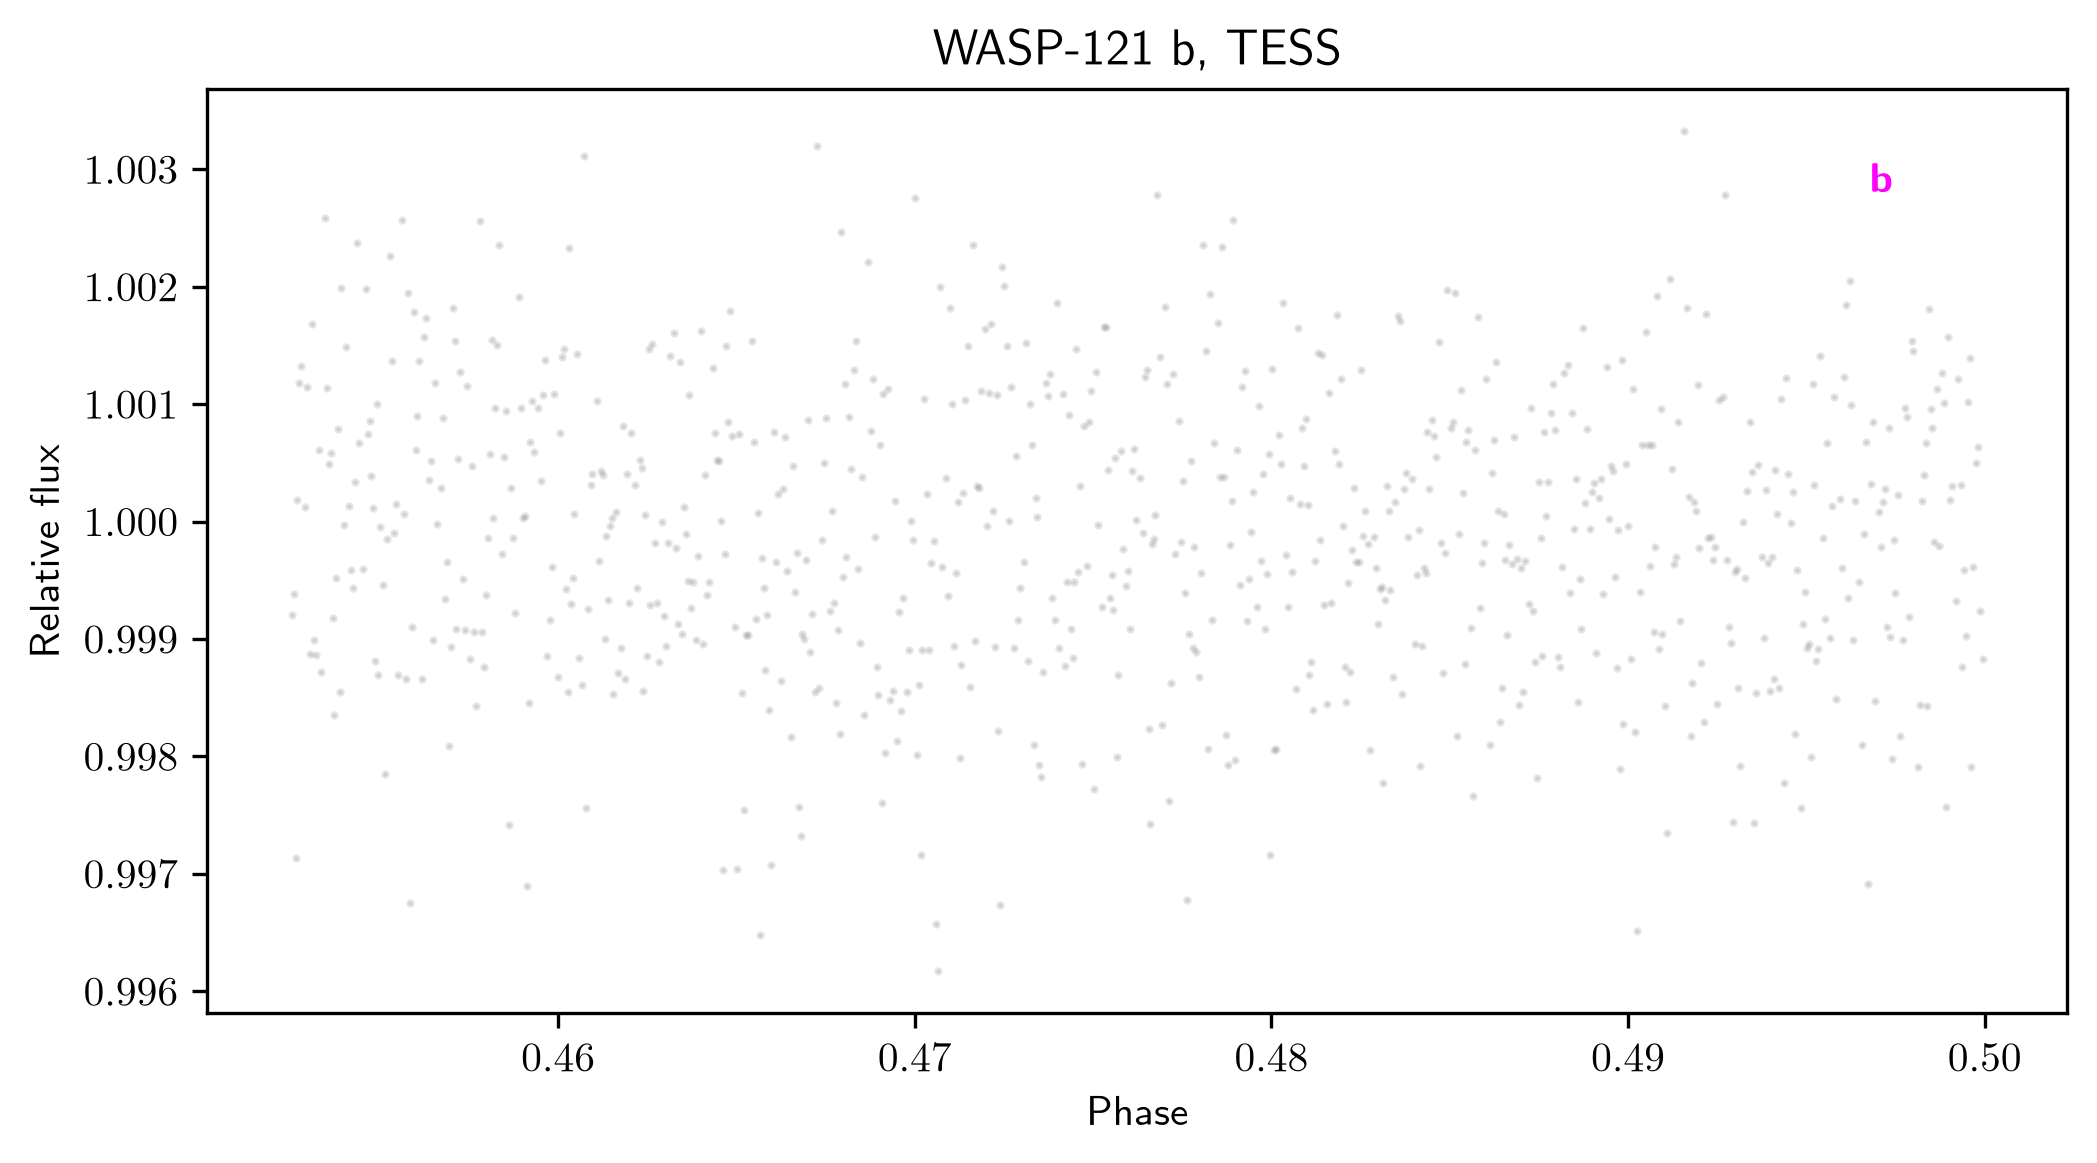

Reading from /Users/tdaylan/Documents/work/git/miletos/examples/WASP-121b/visuals/PhaseCurve_TESS_b_DetrendedSecondaryCenteredZoom_WASP-121b-Daylan2021b_exar.png...


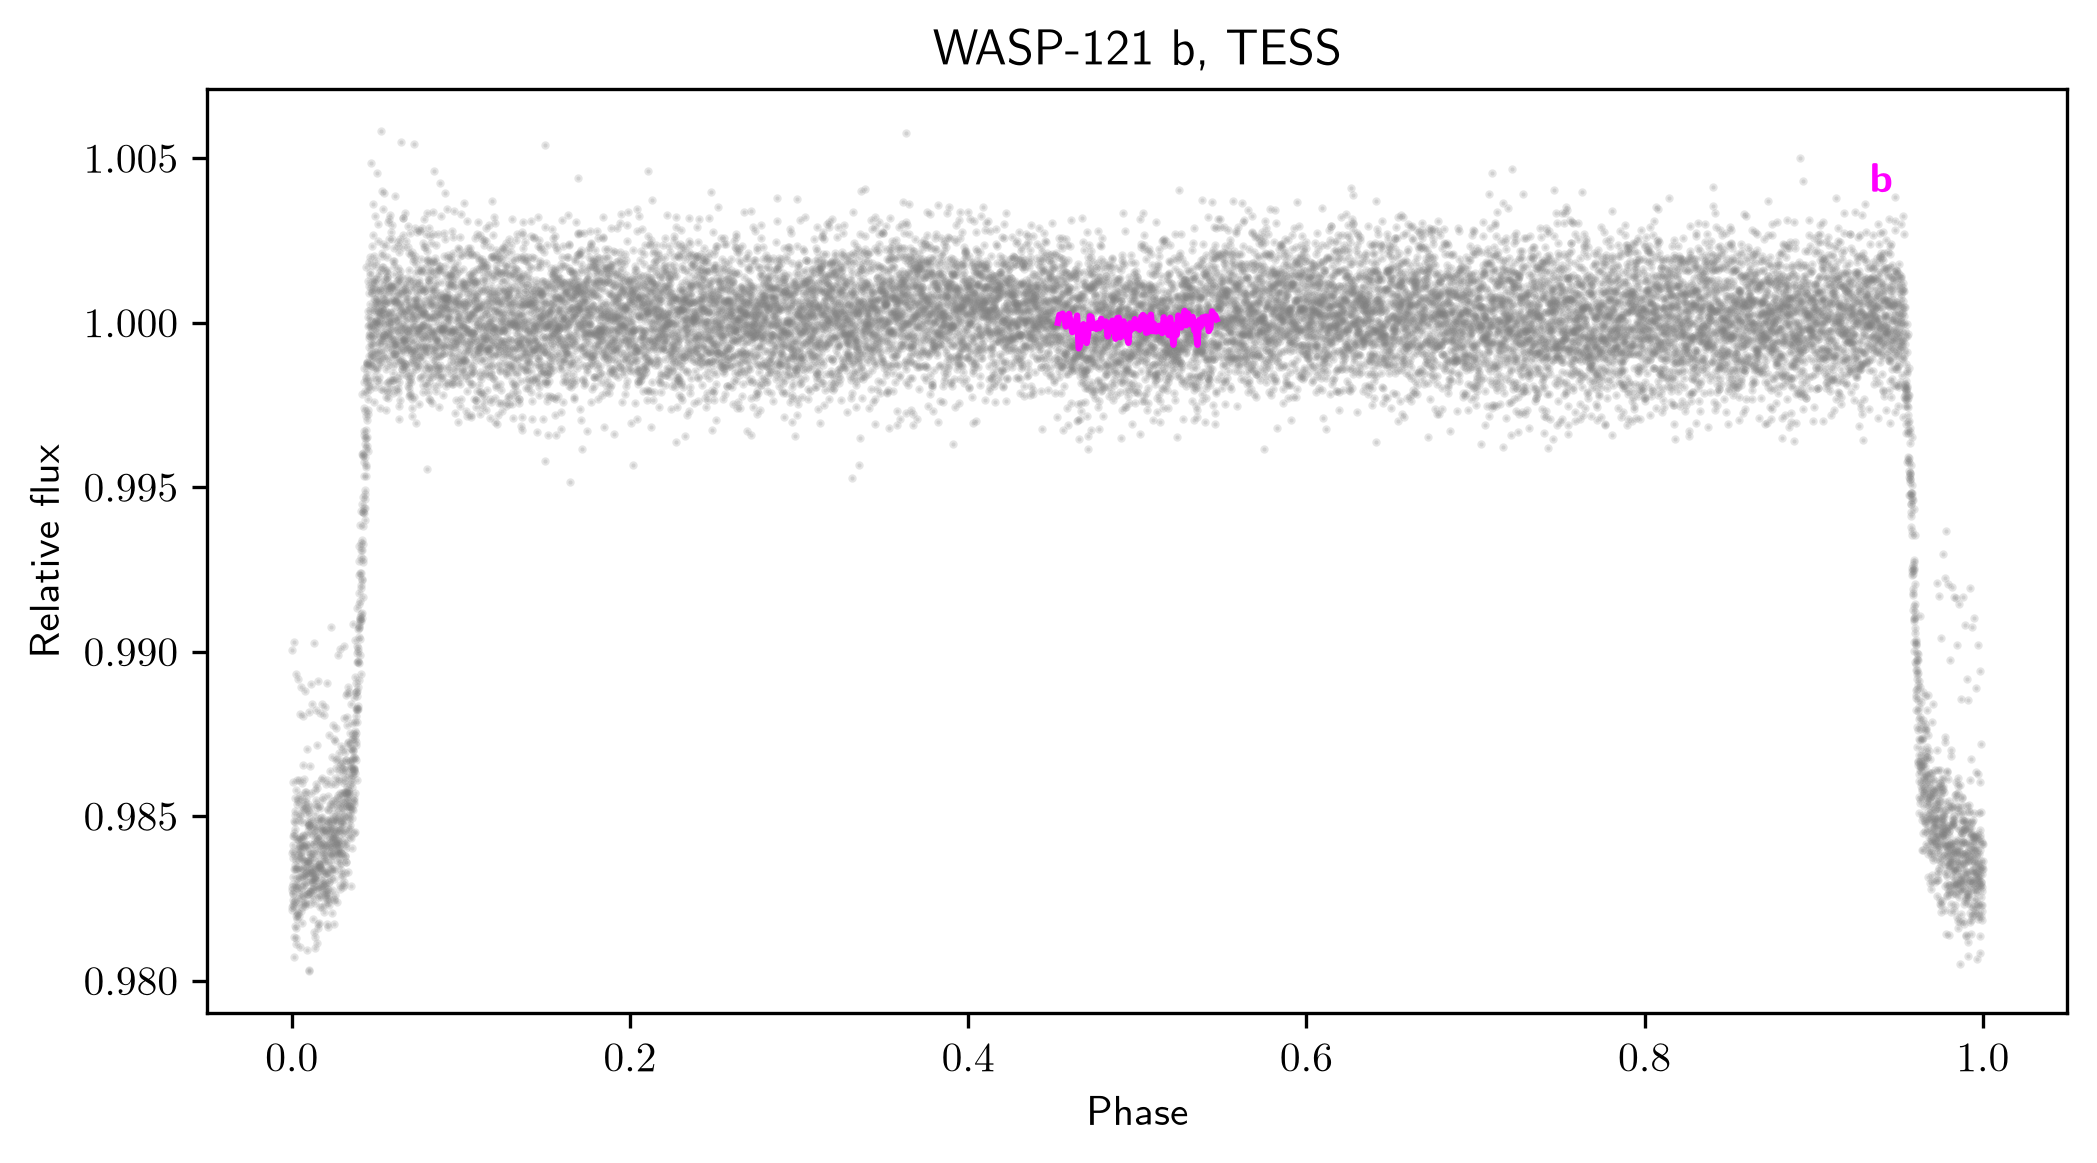

In [2]:
run_observation_preparation = False
if run_observation_preparation:
    daylan2021b.run_daylan2021b_reproduction(typefileplot='png', fit=False)

observation_paths = [
    visual_path / 'RelativeFlux_Raw_TESS_WASP-121b-Daylan2021b.png',
    visual_path / 'PhaseCurve_TESS_b_DetrendedPrimaryCenteredZoom_WASP-121b-Daylan2021b_exar.png',
    visual_path / 'PhaseCurve_TESS_b_DetrendedSecondaryCenteredZoom_WASP-121b-Daylan2021b_exar.png',
]
for path in observation_paths:
    print(f'Reading from {path}...')
    display(Image(filename=str(path)))

## Sample the phase-curve posterior with PCAT

Four chains of 200,000 sweeps each take about 30 minutes. Set `run_posterior_sampling = True` to run them; `boolreus=True` reuses a saved posterior when one is available.

In [3]:
run_posterior_sampling = False
if run_posterior_sampling:
    samples, tmpt, state = daylan2021b.fit_daylan2021b_phase_curve(
        numbchan=4,
        numbsamp=100000,
        numbburn=100000,
        boolreus=True,
    )
    daylan2021b.plot_daylan2021b_phase_curve(samples, tmpt, state)

## Compare with the published results

In [4]:
if run_posterior_sampling:
    for line in daylan2021b.retr_summary_daylan2021b(samples, tmpt):
        print(line)

Reading from /Users/tdaylan/Documents/work/git/miletos/examples/WASP-121b/visuals/TimeSeries_PosteriorMedian.png...


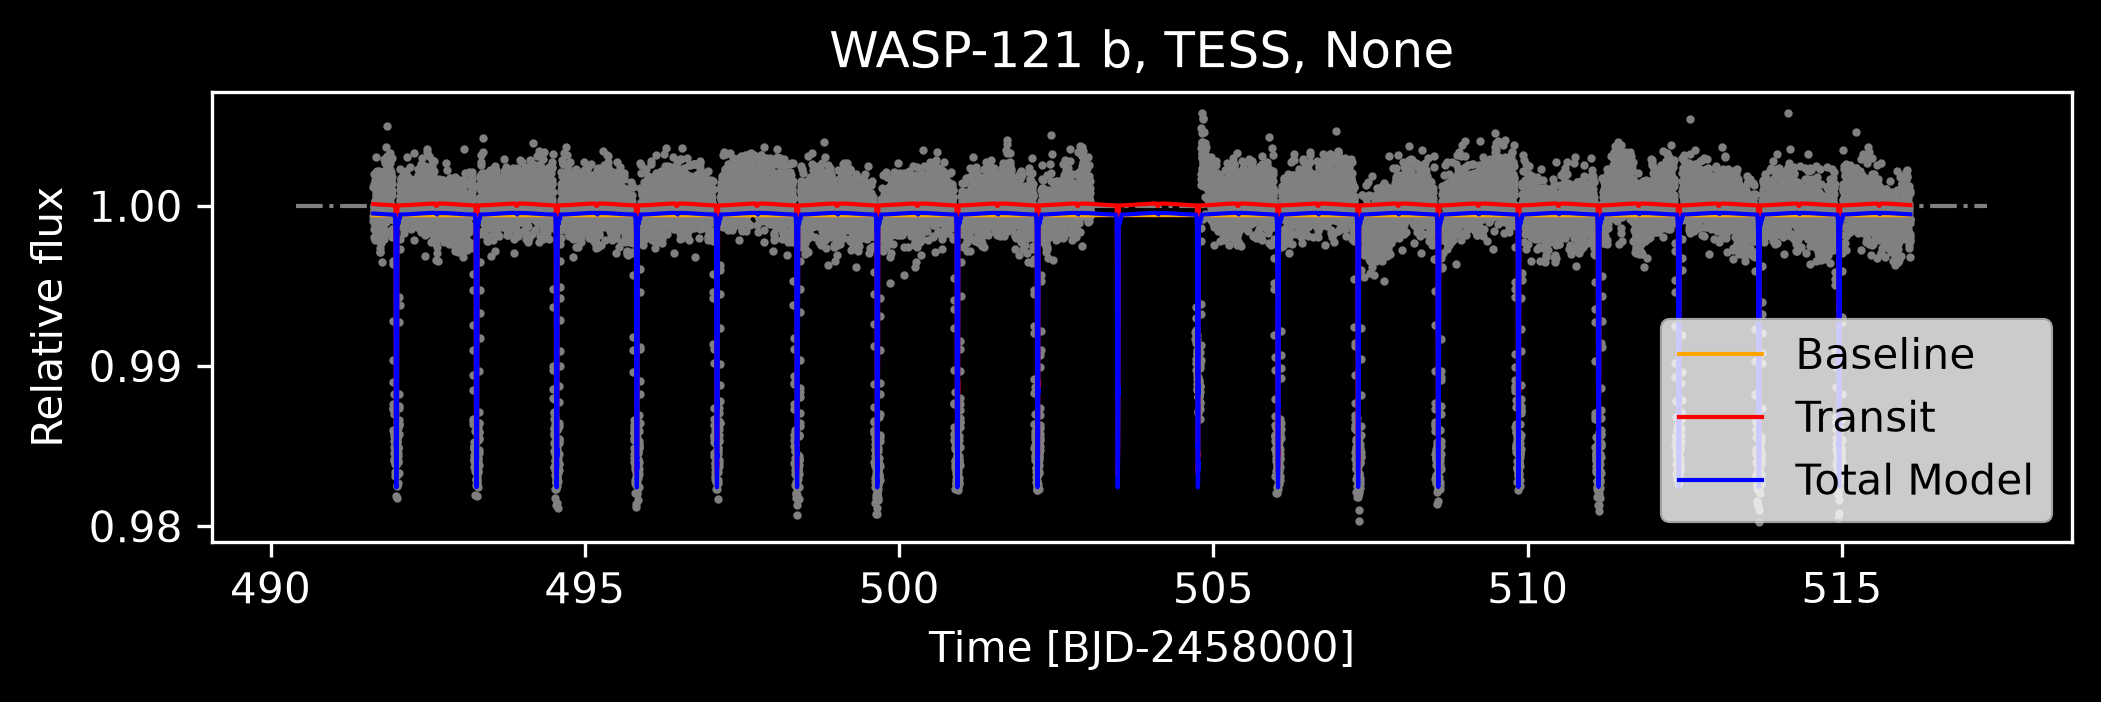

Reading from /Users/tdaylan/Documents/work/git/miletos/examples/WASP-121b/visuals/TimeSeries_ResidualPosteriorMedian.png...


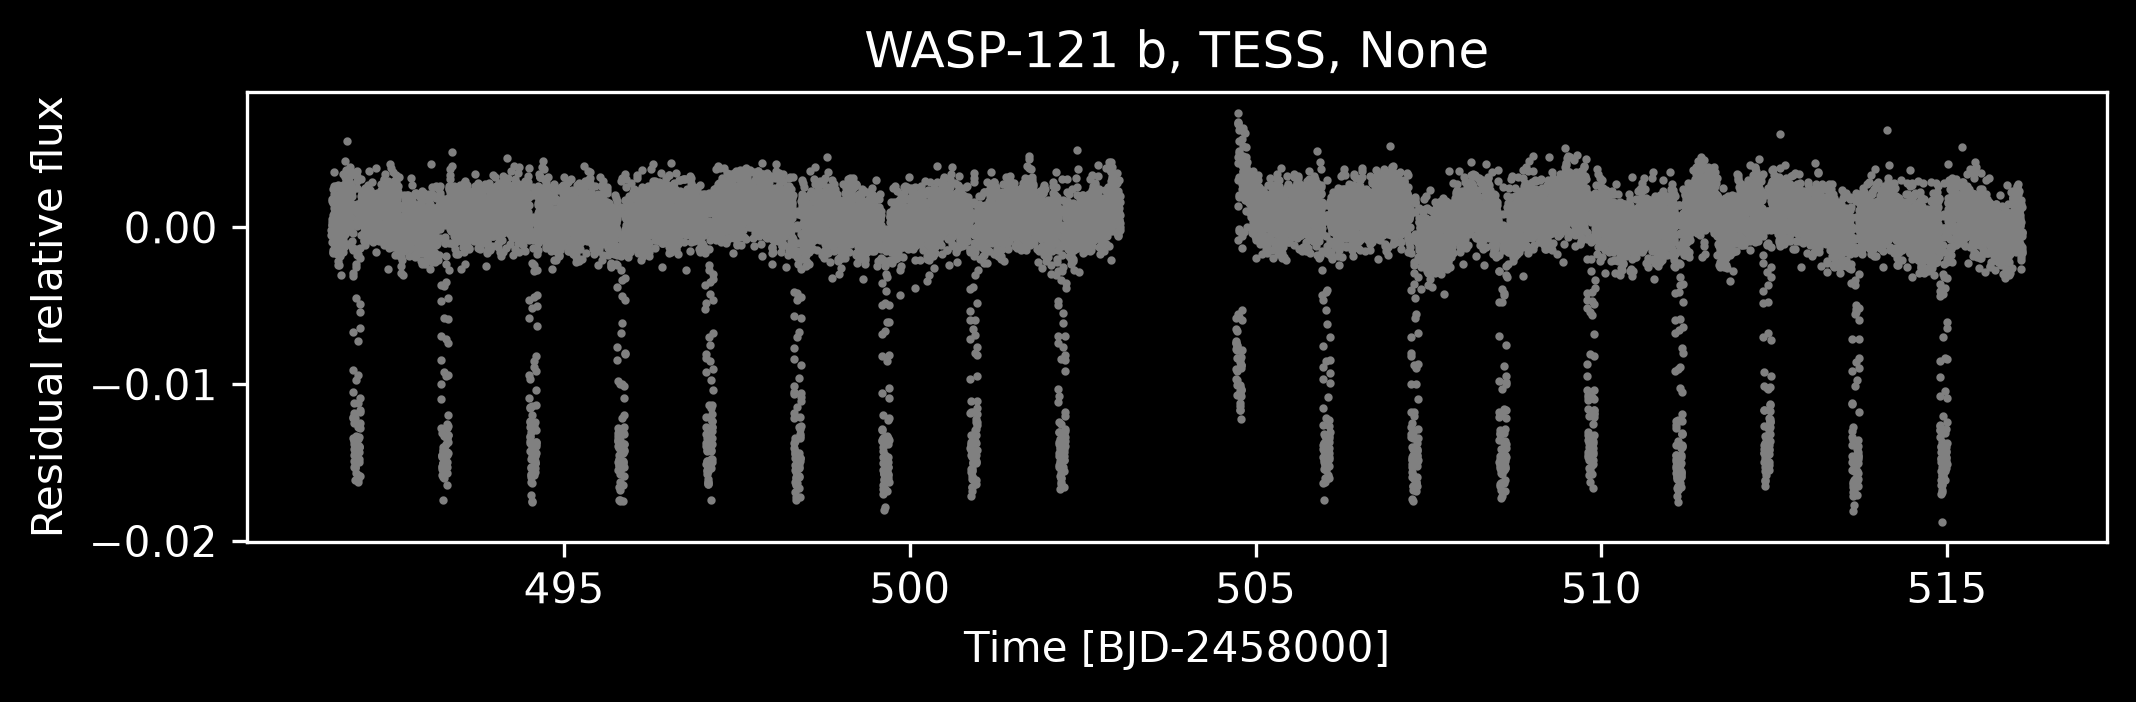

In [5]:
posterior_paths = [
    visual_path / 'TimeSeries_PosteriorMedian.png',
    visual_path / 'TimeSeries_ResidualPosteriorMedian.png',
]
for path in posterior_paths:
    print(f'Reading from {path}...')
    display(Image(filename=str(path)))